# TN2211 Session 5

## Instruments

In [18]:
import sys
sys.path.append("../drivers/")
from tn2211_drivers import *
import glob
import matplotlib.pyplot as plt
import math
from scipy.signal import hilbert

In [2]:
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources()

('ASRL1::INSTR',
 'ASRL2::INSTR',
 'USB0::0xF4EC::0x1103::SDG1XDDX802455::INSTR',
 'USB0::0xF4EC::0x1017::SDS08A0Q808388::INSTR')

In [3]:
scope = Scope("SDS")

Connecting to scope at resource: USB0::0xF4EC::0x1017::SDS08A0Q808388::INSTR
Setting memory depth to 10k points


In [4]:
gen = Generator("SDG")

Connecting to scope at resource: USB0::0xF4EC::0x1103::SDG1XDDX802455::INSTR


## Calculator 

It is always handy to have some code cells to do quick calculations for you. 

In [12]:
R = 1e3 # Ohms
C = 10e-9 # Farads

w_c = 1/R/C
f_c = w_c / 2 / np.pi

print("Corner frequency: %.2e Hz" % f_c)

Corner frequency: 1.59e+04 Hz


In [ ]:
# add cells as needed for your calculations

In [ ]:
# more calculations

## Frequency sweep traces

Some code to help set up and analyze "chirp" frequency sweeps.

In [72]:
def setup_frequency_sweep(start_frequency, stop_frequency, sweep_time=1):
    # Ok, scope time base on screen goes in increments 1, 2, 5, 10...    
    mantissa = float(("%e" %  sweep_time).split("e")[0])
    exponent = float(("%e" %  sweep_time).split("e")[1])
    allowed = np.array([1, 2, 5, 10])
    idx = np.abs(allowed - mantissa).argmin()
    mantissa = allowed[idx]
    sweep_time = float("%fe%d" % (mantissa, exponent))
    print("Picking sweep time %e based on nearest allowed division of scope display" % sweep_time)
    
    # Configurting sweep, page 26 of manual of SDG1000 
    gen.write("C1:SWWV STATE,ON")
    gen.write("C1:SWWV TIME,%f" % sweep_time)
    gen.write("C1:SWWV STOP,%f" % stop_frequency)
    gen.write("C1:SWWV START,%f" % start_frequency)
    
    # This will automatically set up the time base of the scope in a good way :)
    scope.write("TIM:SCAL %f" % (sweep_time/10)) # The display has 10 "divisions"...
    scope.write("TIM:DEL %f" % (sweep_time/2)) # Set horizontal position to show full sweep on screen
    print("Setting memory depth to 1 million points") # Will make trace downloding slow but gives best data
    scope.write("ACQ:MDEP 1M")

# this assumes your traces are acquired as above with the start and stop frequencies at start and end of trace
def make_frequency_response(v, f_start, f_stop):
    f_start = 1e3
    f_stop = 200e3
    f = np.linspace(f_start, f_stop, len(v))
    v_amp = np.abs(hilbert(v))
    # There is some noise in the analytical signal, I will filter it...
    v_amp = np.convolve(v_amp, np.ones(100)/100, "same")
    return f, v_amp

Set up the equipment to sweep from 1 kHz to 200 kHz in 100 ms:

In [73]:
setup_frequency_sweep(1e3, 200e3, 0.4)

Picking sweep time 5.000000e-01 based on nearest allowed division of scope display
Setting memory depth to 1 million points


In [74]:
t,v = scope.get_trace(1, npoints=1e6)

Retreiving 1000000 points


In [75]:
f, v_amp = make_frequency_response(v, 1e3, 200e3)

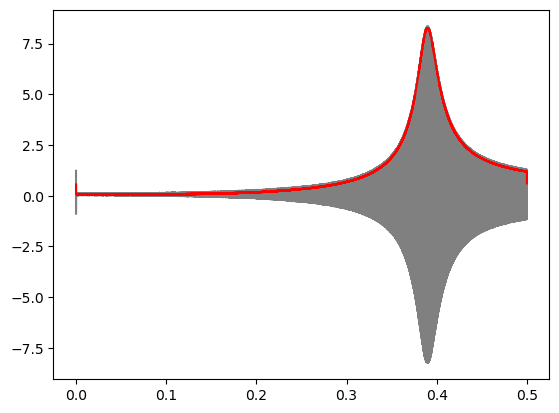

In [78]:
plt.plot(t,v, c='grey')
plt.plot(t, v_amp, c='red')

Now you can make a Bode plot. Here is a starting point for your code. You can also make a function that does the Bode plot. You can even make a function that sets up the sweep, does the meaurement, converts it to dB, and then makes a plot :)

Text(0.5, 0, 'Frequency response (dB)')

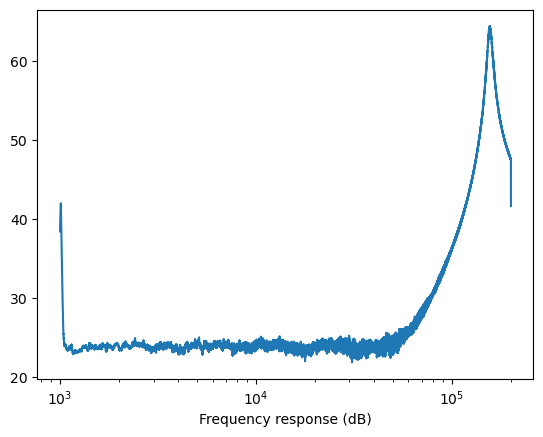

In [66]:
# For a Bode plot, convert this in dB relative the voltage
# applied on your generator

v_gen_ptp = 1
v_gen_amp = v_gen_ptp / 2

v_ratio = ...
dB = ...

plt.plot(f, dB)
plt.xscale("log")
plt.xlabel("Frequency response (dB)")
plt.xlabel("...")
plt.xlim(...,...) # you may want to zoom in a bit

theory = ...
plot.plot(f, theory)
...